In [5]:
import sys
import os

# Point to the CADLabs model using absolute path
cadlabs_model_path = os.path.expanduser('~/CS521/staking-economics-sim/ethereum-economic-model')

sys.path.insert(0, cadlabs_model_path)
os.chdir(cadlabs_model_path)

import radcad
import cadCAD_tools
import matplotlib
print("all ok")

all ok


In [6]:
from experiments.run import run
from model.system_parameters import validator_environments
from model.state_variables import eth_staked
print("CADLabs imports ok")
print("Validator environments:", [v.type for v in validator_environments])

ERROR:root:401 Client Error: Unauthorized for url: https://beaconcha.in/api/v1/epoch/latest
ERROR:root:


CADLabs imports ok
Validator environments: ['diy_hardware', 'diy_cloud', 'pool_staas', 'pool_hardware', 'pool_cloud', 'staas_full', 'staas_self_custodied']


In [7]:
import copy
import logging
import pandas as pd
import matplotlib.pyplot as plt

# Suppress the API warnings
logging.getLogger().setLevel(logging.CRITICAL)

# Import experiment templates
import experiments.templates.time_domain_analysis as time_domain_analysis

# Make a copy of the base simulation
simulation = copy.deepcopy(time_domain_analysis.experiment.simulations[0])

# Run it with default settings first to make sure everything works
df, exceptions = run(simulation)

print("Simulation complete")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

DEBUG:matplotlib:CACHEDIR=/Users/sunwoobaek/.matplotlib


2026-04-18 22:16:51,983 - matplotlib - DEBUG - CACHEDIR=/Users/sunwoobaek/.matplotlib


DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/sunwoobaek/.matplotlib/fontlist-v390.json


2026-04-18 22:16:51,987 - matplotlib.font_manager - DEBUG - Using fontManager instance from /Users/sunwoobaek/.matplotlib/fontlist-v390.json
Simulation complete
Rows: 1080
Columns: ['stage', 'timestamp', 'eth_price', 'eth_supply', 'eth_staked', 'supply_inflation', 'network_issuance', 'pow_issuance', 'number_of_validators_in_activation_queue', 'average_effective_balance', 'number_of_active_validators', 'number_of_awake_validators', 'validator_uptime', 'base_reward', 'validating_rewards', 'validating_penalties', 'source_reward', 'target_reward', 'head_reward', 'block_proposer_reward', 'sync_reward', 'attestation_penalties', 'sync_committee_penalties', 'amount_slashed', 'whistleblower_rewards', 'base_fee_per_gas', 'total_base_fee', 'total_priority_fee_to_miners', 'total_priority_fee_to_validators', 'total_realized_mev_to_miners', 'total_realized_mev_to_validators', 'validator_eth_staked', 'validator_revenue', 'validator_profit', 'validator_revenue_yields', 'validator_profit_yields', 'vali

In [8]:
# --- Scenario 1: Honest validators (high uptime, no slashing) ---
sim_honest = copy.deepcopy(time_domain_analysis.experiment.simulations[0])
sim_honest.model.params.update({
    'validator_uptime_process': [lambda _run, _timestep: 0.98],
    'slashing_events_per_1000_epochs': [0],
})
df_honest, _ = run(sim_honest)
df_honest['behavior'] = 'honest'

# --- Scenario 2: Colluding validators (reduced uptime, higher slashing) ---
sim_colluding = copy.deepcopy(time_domain_analysis.experiment.simulations[0])
sim_colluding.model.params.update({
    'validator_uptime_process': [lambda _run, _timestep: 0.80],
    'slashing_events_per_1000_epochs': [5],
})
df_colluding, _ = run(sim_colluding)
df_colluding['behavior'] = 'colluding'

# --- Scenario 3: Offline validators (minimum uptime) ---
sim_offline = copy.deepcopy(time_domain_analysis.experiment.simulations[0])
sim_offline.model.params.update({
    'validator_uptime_process': [lambda _run, _timestep: 2/3],  # inactivity leak threshold
    'slashing_events_per_1000_epochs': [0],
})
df_offline, _ = run(sim_offline)
df_offline['behavior'] = 'offline'

# --- Scenario 4: Pool validators (good uptime, third-party fee cost) ---
sim_pool = copy.deepcopy(time_domain_analysis.experiment.simulations[0])
sim_pool.model.params.update({
    'validator_uptime_process': [lambda _run, _timestep: 0.95],
    'slashing_events_per_1000_epochs': [1],
    'validator_third_party_costs_per_epoch': [
        [0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10]  # 10% fee across all environments
    ],
})
df_pool, _ = run(sim_pool)
df_pool['behavior'] = 'pool'

print("All scenarios complete")

All scenarios complete


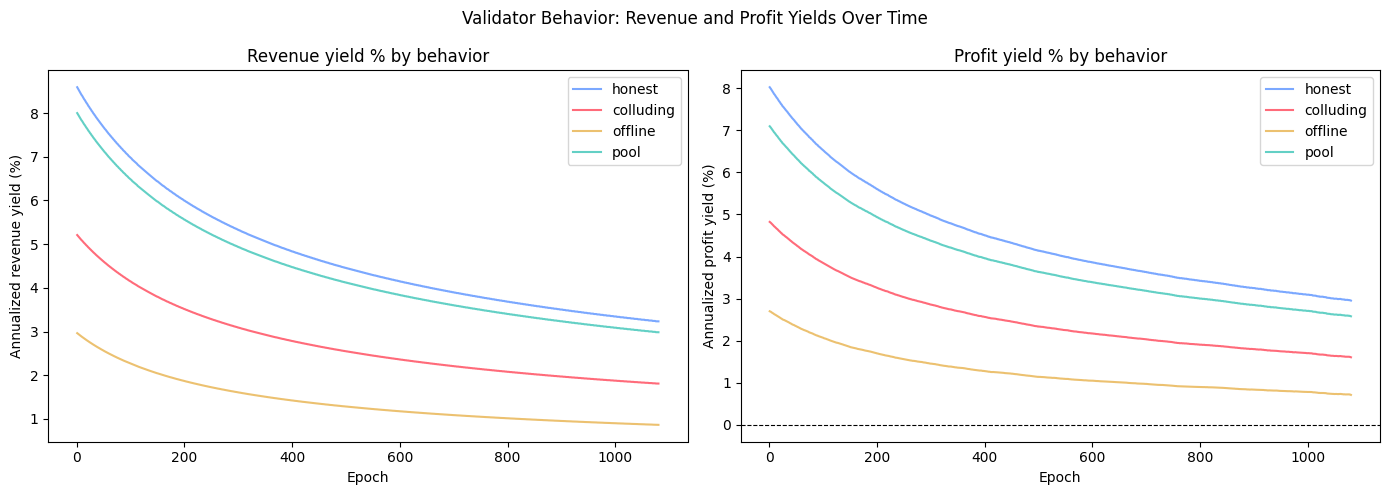

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'honest': '#7ba8ff', 'colluding': '#ff6b7a', 'offline': '#ecc170', 'pool': '#63d0c5'}

for df, label in [(df_honest, 'honest'), (df_colluding, 'colluding'),
                  (df_offline, 'offline'), (df_pool, 'pool')]:
    d = df[df['substep'] == 15]
    axes[0].plot(d['timestep'], d['total_revenue_yields_pct'], label=label, color=colors[label])
    axes[1].plot(d['timestep'], d['total_profit_yields_pct'],  label=label, color=colors[label])

axes[0].set_title('Revenue yield % by behavior')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Annualized revenue yield (%)')
axes[0].legend()

axes[1].set_title('Profit yield % by behavior')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Annualized profit yield (%)')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].legend()

plt.suptitle('Validator Behavior: Revenue and Profit Yields Over Time')
plt.tight_layout()
plt.savefig('experiment_results.png')
plt.show()

In [13]:
# print(df_honest['substep'].unique())
# print(df_honest['timestep'].unique()[:10])
# print(df_honest[['timestep', 'substep', 'total_revenue_yields_pct']].head(20))

In [12]:
EPOCHS_PER_YEAR = 82180

print(f"\n{'Behavior':<12} {'Final revenue yield':>20} {'Final profit yield':>20} {'Profitable?':>12}")
print("-" * 68)

for df, label in [(df_honest, 'honest'), (df_colluding, 'colluding'),
                  (df_offline, 'offline'), (df_pool, 'pool')]:
    d = df[df['substep'] == 15]
    final_revenue = d['total_revenue_yields_pct'].iloc[-1]
    final_profit  = d['total_profit_yields_pct'].iloc[-1]
    profitable = "Yes" if final_profit > 0 else "No"
    print(f"{label:<12} {final_revenue:>19.2f}% {final_profit:>19.2f}% {profitable:>12}")


Behavior      Final revenue yield   Final profit yield  Profitable?
--------------------------------------------------------------------
honest                      3.23%                2.95%          Yes
colluding                   1.81%                1.61%          Yes
offline                     0.86%                0.71%          Yes
pool                        2.98%                2.58%          Yes


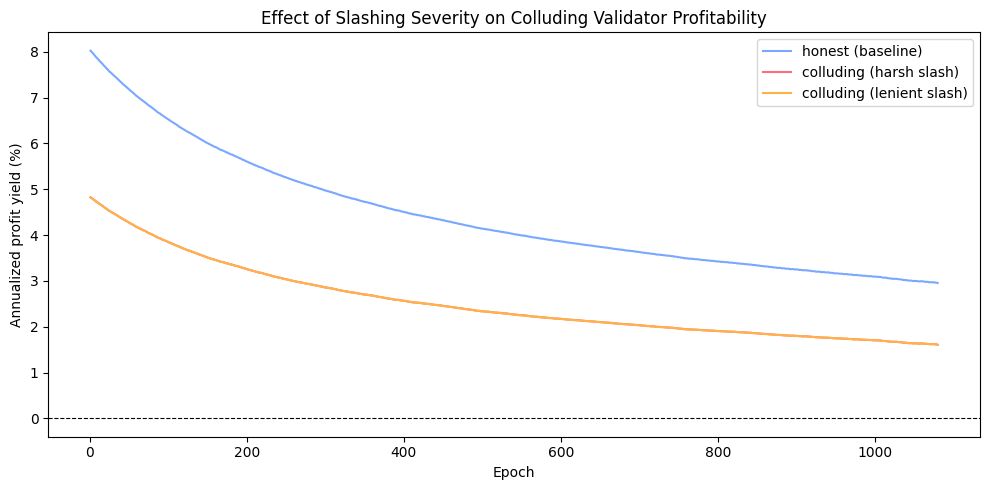

In [14]:
# Compare harsh vs lenient slashing for colluding validators
sim_harsh = copy.deepcopy(time_domain_analysis.experiment.simulations[0])
sim_harsh.model.params.update({
    'validator_uptime_process': [lambda _run, _timestep: 0.80],
    'slashing_events_per_1000_epochs': [10],  # harsh
})
df_harsh, _ = run(sim_harsh)

sim_lenient = copy.deepcopy(time_domain_analysis.experiment.simulations[0])
sim_lenient.model.params.update({
    'validator_uptime_process': [lambda _run, _timestep: 0.80],
    'slashing_events_per_1000_epochs': [1],  # lenient
})
df_lenient, _ = run(sim_lenient)

fig, ax = plt.subplots(figsize=(10, 5))
for df, label, color in [
    (df_honest,  'honest (baseline)',       '#7ba8ff'),
    (df_harsh,   'colluding (harsh slash)', '#ff6b7a'),
    (df_lenient, 'colluding (lenient slash)','#ffb347'),
]:
    d = df[df['substep'] == 15]
    ax.plot(d['timestep'], d['total_profit_yields_pct'], label=label, color=color)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Annualized profit yield (%)')
ax.set_title('Effect of Slashing Severity on Colluding Validator Profitability')
ax.legend()
plt.tight_layout()
plt.savefig('slashing_comparison.png')
plt.show()

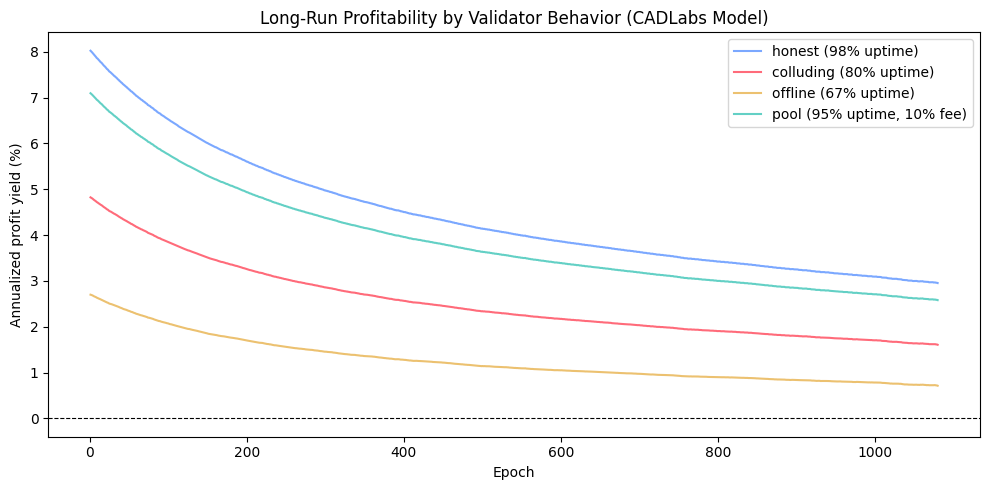

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

scenarios = [
    (df_honest,    'honest (98% uptime)',          '#7ba8ff'),
    (df_colluding, 'colluding (80% uptime)',        '#ff6b7a'),
    (df_offline,   'offline (67% uptime)',          '#ecc170'),
    (df_pool,      'pool (95% uptime, 10% fee)',    '#63d0c5'),
]

for df, label, color in scenarios:
    d = df[df['substep'] == 15]
    ax.plot(d['timestep'], d['total_profit_yields_pct'], label=label, color=color)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Annualized profit yield (%)')
ax.set_title('Long-Run Profitability by Validator Behavior (CADLabs Model)')
ax.legend()
plt.tight_layout()
plt.savefig('behavior_comparison_final.png')
plt.show()

In [16]:
import copy
from radcad import Experiment, Engine, Backend
import experiments.templates.time_domain_analysis as time_domain_analysis

sim = copy.deepcopy(time_domain_analysis.experiment.simulations[0])

# Define all 4 behavior scenarios as parameter sweeps (subsets)
sim.model.params.update({
    'validator_uptime_process': [
        lambda _run, _timestep: 0.98,   # subset 0: honest
        lambda _run, _timestep: 0.80,   # subset 1: colluding
        lambda _run, _timestep: 2/3,    # subset 2: offline
        lambda _run, _timestep: 0.95,   # subset 3: pool
    ],
    'slashing_events_per_1000_epochs': [0, 5, 0, 1],
    'validator_third_party_costs_per_epoch': [
        [0.0]*7,   # honest: no fee
        [0.0]*7,   # colluding: no fee
        [0.0]*7,   # offline: no fee
        [0.10]*7,  # pool: 10% fee
    ],
})

# Run all subsets in one call
df_all, exceptions = run(sim)

print(f"Subsets: {df_all['subset'].unique()}")
print(f"Total rows: {len(df_all)}")

Subsets: [0 1 2 3]
Total rows: 4320


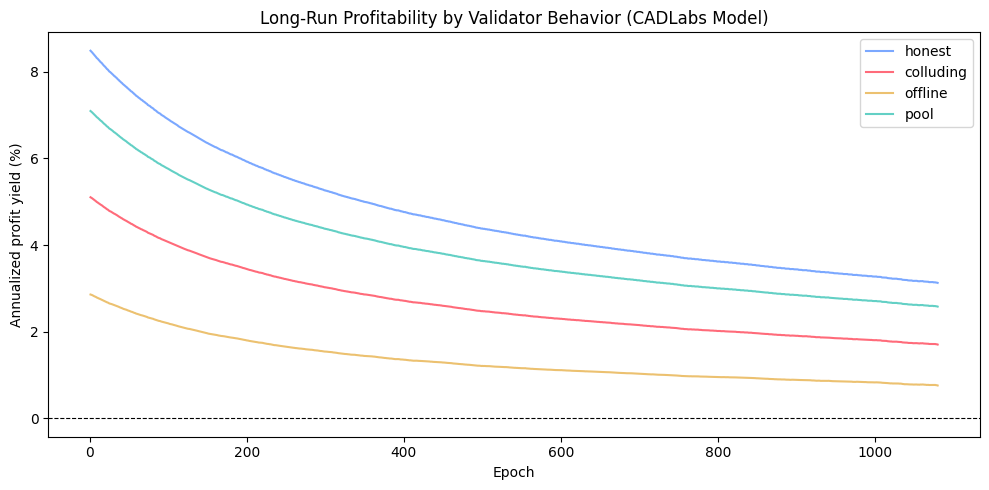

In [17]:
subset_labels = {0: 'honest', 1: 'colluding', 2: 'offline', 3: 'pool'}
colors = {'honest': '#7ba8ff', 'colluding': '#ff6b7a', 'offline': '#ecc170', 'pool': '#63d0c5'}

fig, ax = plt.subplots(figsize=(10, 5))

for subset_id, label in subset_labels.items():
    d = df_all[(df_all['subset'] == subset_id) & (df_all['substep'] == 15)]
    ax.plot(d['timestep'], d['total_profit_yields_pct'], label=label, color=colors[label])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Annualized profit yield (%)')
ax.set_title('Long-Run Profitability by Validator Behavior (CADLabs Model)')
ax.legend()
plt.tight_layout()
plt.savefig('behavior_sweep_final.png')
plt.show()